# Creating the CNN
We will be using a Convolutional Neural Network to predict if audio has been deepfaked.

In [1]:
!pip install tensorflow

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load your processed data
data = np.load('processed_data.npz')
X_train, y_train = data['x_train'], data['y_train']
X_val, y_val = data['x_val'], data['y_val']
X_test, y_test = data['x_test'], data['y_test']

print(f"Ready to train on {X_train.shape[0]} samples of shape {X_train.shape[1:]}")

Ready to train on 2000 samples of shape (128, 44, 1)


# Create the Model



In [8]:
model = models.Sequential([
    # Layer 1: Input Layer + Convolution
    # 32 filters of size 3x3 to find basic edge/texture patterns
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 44, 1)),
    layers.MaxPooling2D((2, 2)), # Shrinks the image to focus on key features
    
    # Layer 2: Deeper features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Layer 3: Flattening and Dense Layers
    layers.Flatten(), # Turns the 2D image into a 1D list of numbers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5), # Randomly shuts off neurons to prevent "memorization" (Overfitting)
    
    # Layer 4: Output Layer
    # Use 'sigmoid' for binary classification (0 or 1)
    layers.Dense(1, activation='sigmoid')
])

In [9]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary() # Prints the internal structure of your CNN

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 42, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 21, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 19, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 17280)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,105,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,124,865 (4.29 MB)

 Trainable params: 1,124,865 (4.29 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,          # How many times to look at the entire dataset
    batch_size=32,      # How many images to look at before updating weights
    validation_data=(X_val, y_val)
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5590 - loss: 0.6905 - val_accuracy: 0.5410 - val_loss: 0.6539
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7045 - loss: 0.5923 - val_accuracy: 0.8210 - val_loss: 0.4953
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7885 - loss: 0.4715 - val_accuracy: 0.8130 - val_loss: 0.4093
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8175 - loss: 0.4018 - val_accuracy: 0.8530 - val_loss: 0.3558
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8330 - loss: 0.3562 - val_accuracy: 0.8530 - val_loss: 0.3225
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8560 - loss: 0.3041 - val_accuracy: 0.8630 - val_loss: 0.2868
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.8710 - loss: 0.2736 - val_accuracy: 0.8835 - val_loss: 0.2655
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.8960 - loss: 0.2211 - val_accuracy: 0.9175 - v

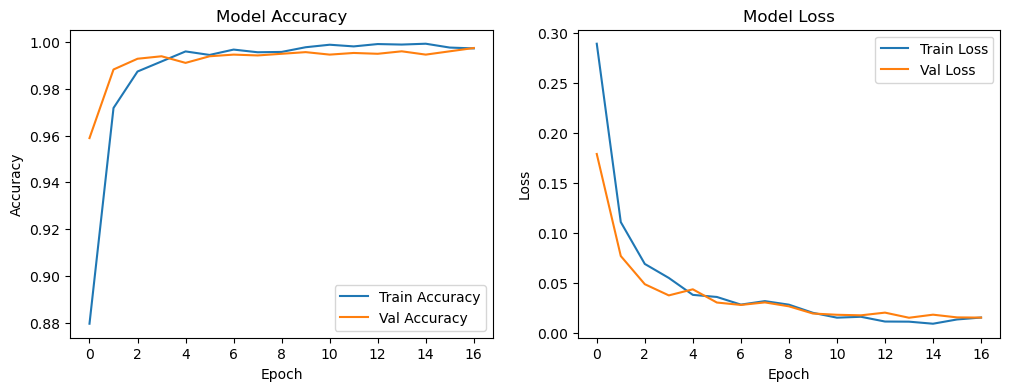

In [5]:
import matplotlib.pyplot as plt

# 1. Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# 2. Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# Testing with the Test Data

In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

34/34 - 1s - 21ms/step - accuracy: 0.5101 - loss: 1.7805

Final Test Accuracy: 51.01%


34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step


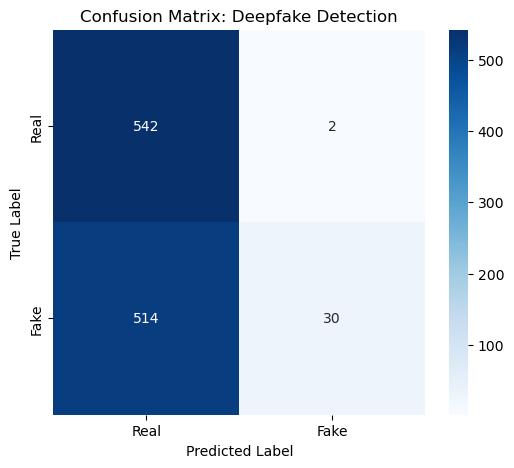

              precision    recall  f1-score   support

        Real       0.51      1.00      0.68       544
        Fake       0.94      0.06      0.10       544

    accuracy                           0.53      1088
   macro avg       0.73      0.53      0.39      1088
weighted avg       0.73      0.53      0.39      1088



In [84]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Get the model's predictions (probabilities)
y_pred_probs = model.predict(X_test)

# 2. Convert probabilities to hard labels (0 or 1)
# Since we used a sigmoid output, anything > 0.5 is "Fake" (1)
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Create the Matrix
cm = confusion_matrix(y_test, y_pred)

# 4. Plot it beautifully
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Deepfake Detection')
plt.show()

# 5. Print the full report (Precision, Recall, F1-Score)
print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))